In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv('noshowappointments.csv')
df

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903.0,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62.0,JARDIM DA PENHA,NaN,1.0,0.0,0.0,0.0,0.0,0.0
1,5.589978e+14,5642503.0,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56.0,JARDIM DA PENHA,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.262962e+12,5642549.0,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62.0,MATA DA PRAIA,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,8.679512e+11,5642828.0,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8.0,PONTAL DE CAMBURI,0.0,0.0,0.0,0.0,NaN,0.0,0.0
4,8.841186e+12,5642494.0,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56.0,JARDIM DA PENHA,0.0,1.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768.0,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56.0,MARIA ORTIZ,0.0,0.0,0.0,0.0,0.0,1.0,0.0
110523,3.596266e+12,5650093.0,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51.0,MARIA ORTIZ,0.0,NaN,0.0,NaN,0.0,1.0,0.0
110524,3.596266e+12,5630692.0,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21.0,MARIA ORTIZ,0.0,0.0,0.0,0.0,0.0,1.0,0.0
110525,9.213493e+13,5630323.0,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38.0,MARIA ORTIZ,NaN,0.0,0.0,0.0,0.0,1.0,0.0


In [3]:
missing_per_column = df.isna().sum()
total_missing = missing_per_column.sum()

print(missing_per_column)
print("Total missing values:", total_missing)

PatientId             0
AppointmentID         0
Gender                0
ScheduledDay          0
AppointmentDay        0
Age                5605
Neighbourhood         0
Scholarship        5471
Hipertension       4683
Diabetes          10271
Alcoholism        11855
Handcap            6724
SMS_received       5599
No-show            1105
dtype: int64
Total missing values: 51313


Number of tuples with specific missing values:
1    29028
2     4812
3      413
4       27
5     1957
6      243
Name: count, dtype: int64


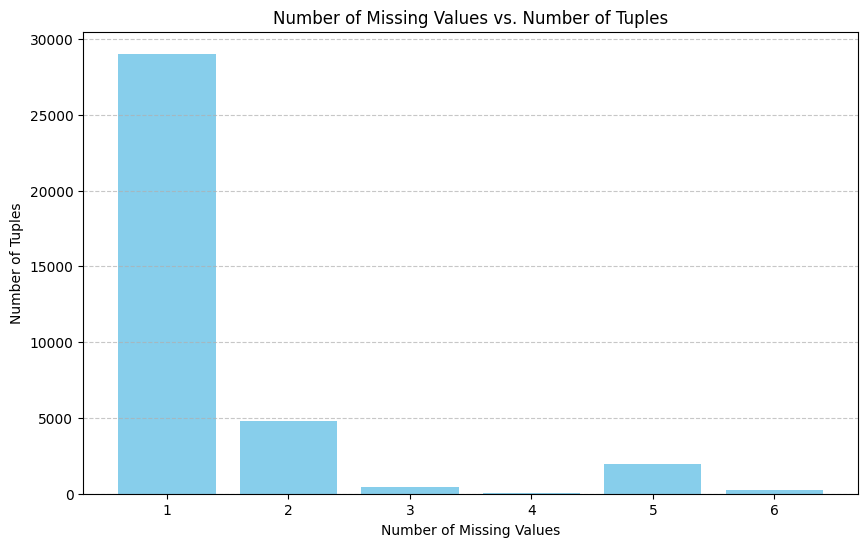

Number of tuples with >=50% of attributes missing: 10
After dropping tuples with >=50% missing values, the dataset has 110517 rows.
After dropping tuples with missing 'SalePrice' attribute, the dataset has 109414 rows.
Cleaned dataset saved as 'noshowappointments_updated.csv'.


In [5]:
missing_counts = df.isnull().sum(axis=1)

missing_value_distribution = missing_counts.value_counts().sort_index().loc[1:6]

print("Number of tuples with specific missing values:")
print(missing_value_distribution)


plt.figure(figsize=(10, 6))
plt.bar(missing_value_distribution.index, missing_value_distribution.values, color='skyblue')
plt.xlabel('Number of Missing Values')
plt.ylabel('Number of Tuples')
plt.title('Number of Missing Values vs. Number of Tuples')
plt.xticks(range(missing_value_distribution.index.min(), missing_value_distribution.index.max() + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


threshold = len(df.columns) / 2

tuples_with_high_missing = (missing_counts >= threshold).sum()
print(f"Number of tuples with >=50% of attributes missing: {tuples_with_high_missing}")


df_cleaned = df[missing_counts < threshold]
print(f"After dropping tuples with >=50% missing values, the dataset has {len(df_cleaned)} rows.")


df_target_cleaned = df_cleaned.dropna(subset=['No-show'])
print(f"After dropping tuples with missing 'SalePrice' attribute, the dataset has {len(df_target_cleaned)} rows.")

df_target_cleaned.to_csv('noshowappointments_updated.csv', index=False)
print("Cleaned dataset saved as 'noshowappointments_updated.csv'.")
